# Diabetes Prediction - Exploratory Data Analysis

### Project Overview

This notebook performs Exploratory Data Analysis (EDA) on the Pima Indians Diabetes Dataset. The objective is to understand the dataset, identify patterns, detect data quality issues, and discover relationships between health-related features and diabetes outcomes. The insights obtained from this analysis will support data preprocessing and machine learning model development.

# 1. Introduction

Exploratory Data Analysis (EDA) is the process of examining and understanding a dataset before building a machine learning model. It helps identify missing values, detect outliers, understand feature distributions, and discover relationships between variables.

In this notebook, we analyze the Diabetes dataset to gain meaningful insights and prepare the data for predictive modeling.

# 2. Import Libraries

The following Python libraries are used throughout this notebook for data manipulation, visualization, and analysis.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

plt.style.use("ggplot")

# 3. Load Dataset

The diabetes dataset is loaded into a Pandas DataFrame for analysis.

In [4]:
df = pd.read_csv("../data/diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


#First 5 rows

# 4. Dataset Overview

This section provides an overview of the dataset, including its dimensions, column names, data types, and summary statistics.

## 4.1 First Five Rows

The first five rows provide an initial understanding of the dataset structure and feature values.

In [5]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 4.2 Dataset Shape

The shape of the dataset indicates the number of rows and columns.

In [6]:
df.shape

(768, 9)

## 4.3 Dataset Information

This section displays the data type and non-null count for each feature.

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


## 4.4 Statistical Summary

Summary statistics provide information about the distribution of numerical variables, including mean, standard deviation, minimum, maximum, and quartiles.

In [8]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Observation

- The dataset contains numerical features related to patient health.
- All columns are numerical.
- No missing (NaN) values are present.
- Some features contain zero values that may represent invalid or missing measurements and will be examined in the next section.

# 5. Data Quality Assessment

This section evaluates the quality of the dataset by checking for missing values and identifying invalid values that may affect model performance.

## 5.1 Missing Values

Missing values can negatively impact machine learning models. Therefore, the dataset is checked to identify any null (NaN) values.

In [9]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

### Observation

- The dataset does not contain any missing (NaN) values.
- Every feature has complete records.
- No missing value imputation is required.

## 5.2 Invalid Zero Values

Although the dataset contains no missing values, some medical measurements contain zero values. For features such as Glucose, Blood Pressure, BMI, Skin Thickness, and Insulin, a value of zero is medically unrealistic and should be treated as an invalid value during preprocessing.

In [10]:
columns = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

(df[columns] == 0).sum()

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

### Observation

- No missing values were found in the dataset.
- However, several medical features contain zero values.
- Zero values in Glucose, Blood Pressure, Skin Thickness, Insulin, and BMI are medically unrealistic.
- These values will be handled during the data preprocessing stage before training the machine learning model.

# 6. Target Variable Analysis

The target variable represents whether a patient has diabetes or not. Analyzing its distribution helps us understand the class balance in the dataset, which is important for selecting appropriate machine learning evaluation techniques.

## 6.1 Distribution of the Target Variable

The `Outcome` column is the target variable in this dataset.

- '0'→ Non-diabetic patient
- '1' → Diabetic patient

The following analysis shows the number of patients belonging to each class.

In [11]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

## 6.2 Count Plot of the Target Variable

A count plot provides a visual representation of the number of diabetic and non-diabetic patients in the dataset.

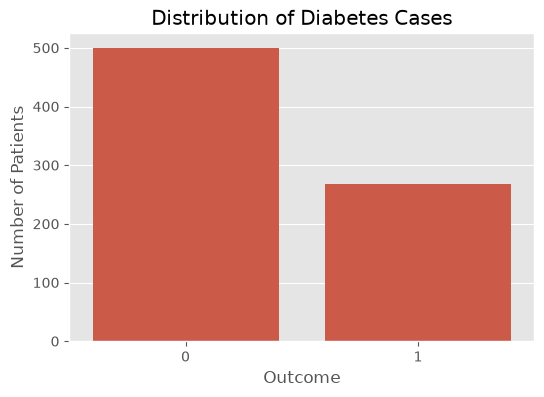

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='Outcome')

plt.title("Distribution of Diabetes Cases")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")

plt.show()

## 6.3 Percentage Distribution

The percentage distribution helps determine whether the dataset is balanced or imbalanced.

In [13]:
(df['Outcome'].value_counts(normalize=True) * 100).round(2)

Outcome
0    65.1
1    34.9
Name: proportion, dtype: float64

### Observation

- The dataset contains more non-diabetic patients than diabetic patients.
- Approximately 65% of the records belong to the non-diabetic class, while about 35% belong to the diabetic class.
- The dataset is moderately imbalanced but still suitable for building classification models.
- Evaluation metrics such as Precision, Recall, F1-score, and ROC-AUC should be considered in addition to accuracy.

# 7. Correlation Analysis

Correlation analysis measures the strength and direction of relationships between numerical variables. It helps identify features that are most closely associated with the target variable and can provide useful insights for feature selection.

## 7.1 Correlation Matrix

The correlation matrix shows the pairwise correlation coefficients between all numerical features in the dataset. The coefficient values range from **-1 to +1**, where:

- '+1' indicates a perfect positive correlation.
- '0' indicates no linear correlation.
- '-1' indicates a perfect negative correlation.

In [14]:
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


## 7.2 Correlation Heatmap

A heatmap provides a visual representation of the correlation matrix, making it easier to identify strong positive and negative relationships between features.

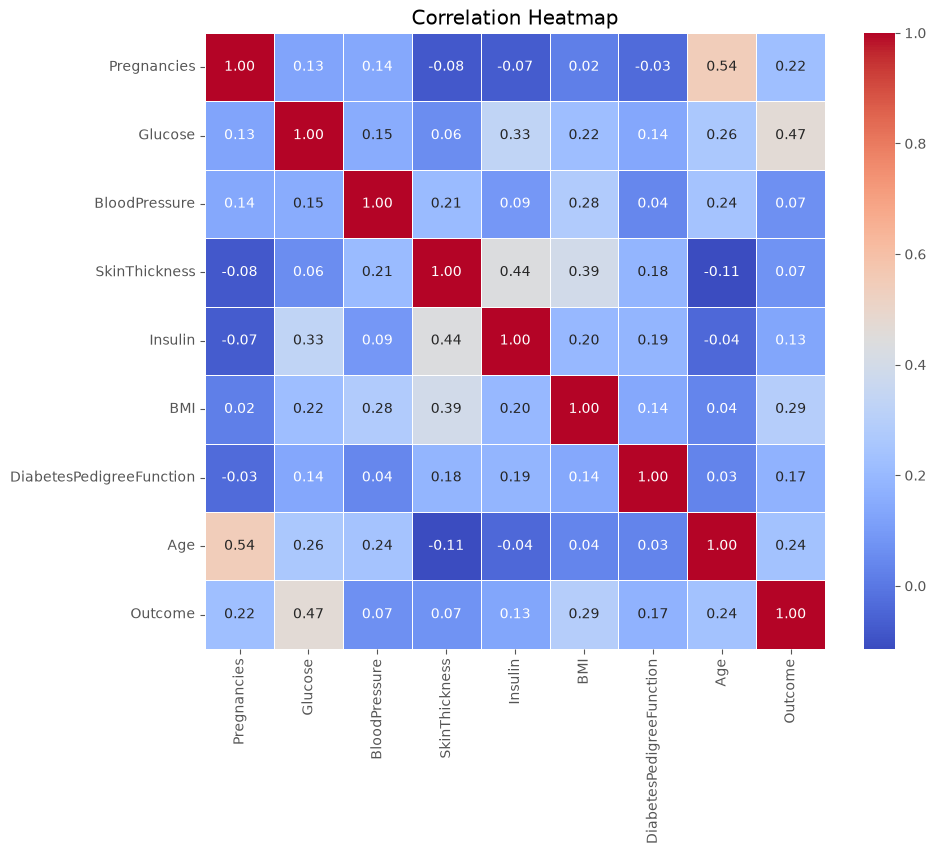

In [15]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

## 7.3 Correlation with the Target Variable

The following analysis displays the correlation of each feature with the target variable (`Outcome`). This helps identify the most important predictors of diabetes.

In [16]:
df.corr()['Outcome'].sort_values(ascending=False)

Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64

### Observation

- Glucose has the strongest positive correlation with the target variable, indicating that higher glucose levels are associated with a greater likelihood of diabetes.
- BMI, Age, and Pregnancies also show moderate positive correlations with diabetes.
- Blood Pressure and Skin Thickness have relatively weak correlations with the target variable.
- Correlation analysis provides useful insights into feature importance but does not imply a cause-and-effect relationship.

# 8. Univariate Analysis

Univariate analysis focuses on examining each feature individually. It helps understand the distribution of values, identify skewness, and detect unusual observations that may require preprocessing before model training.

## 8.1 Glucose Distribution

Glucose level is one of the most significant indicators of diabetes. Analyzing its distribution helps understand the spread of glucose measurements among patients.

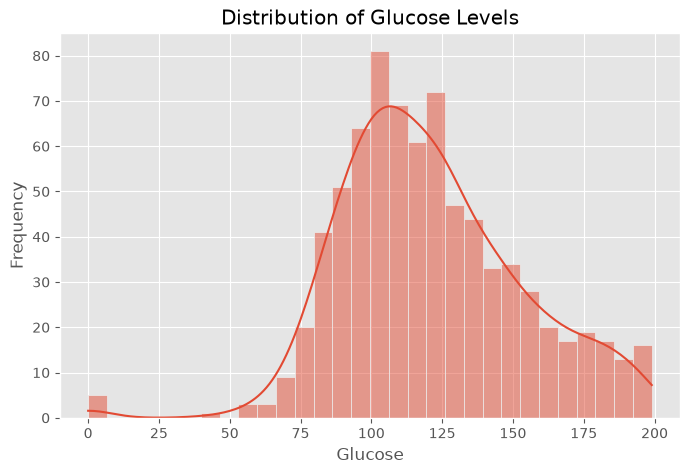

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(df['Glucose'], bins=30, kde=True)

plt.title("Distribution of Glucose Levels")
plt.xlabel("Glucose")
plt.ylabel("Frequency")

plt.show()

### Observation

- Most glucose values are concentrated between approximately 80 and 150.
- The distribution is slightly right-skewed.
- A small number of patients have very high glucose levels.
- Glucose appears to be an important feature for diabetes prediction.

## 8.2 BMI Distribution

Body Mass Index (BMI) is an important health indicator that measures body fat based on height and weight. This analysis shows how BMI values are distributed.

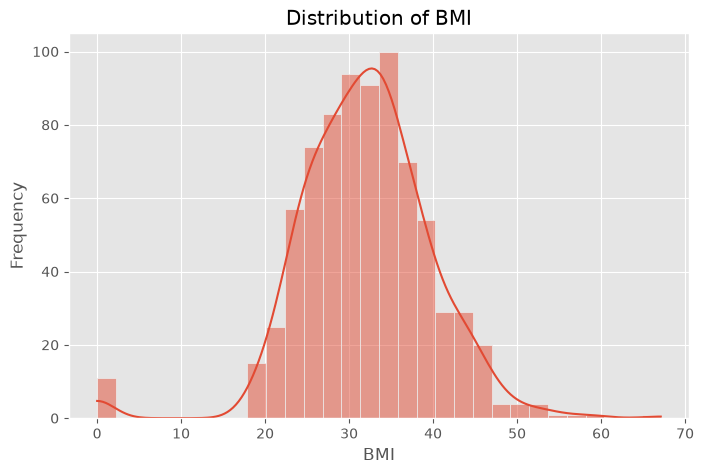

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(df['BMI'], bins=30, kde=True)

plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Frequency")

plt.show()

### Observation

- Most BMI values are concentrated between 25 and 40.
- The distribution is slightly right-skewed.
- A few patients have unusually high BMI values.

## 8.3 Age Distribution

This visualization shows the distribution of patient ages in the dataset.

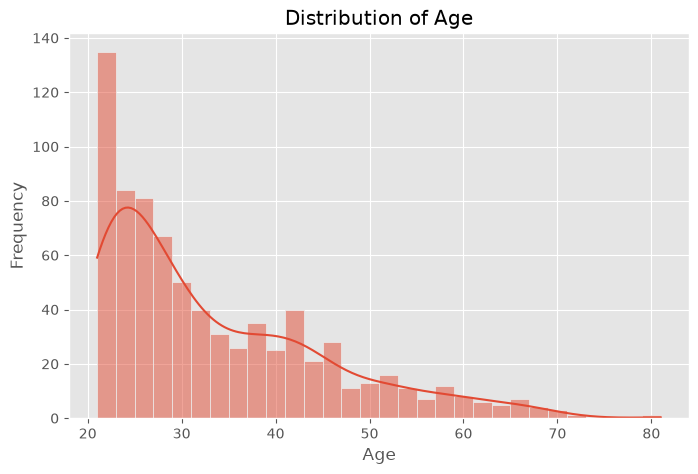

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=30, kde=True)

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

### Observation

- Most patients are between 20 and 40 years of age.
- The dataset contains fewer older patients.
- The age distribution is positively skewed.

In [ ]:
## 8.4 Insulin Distribution

This analysis examines the distribution of insulin levels among patients.

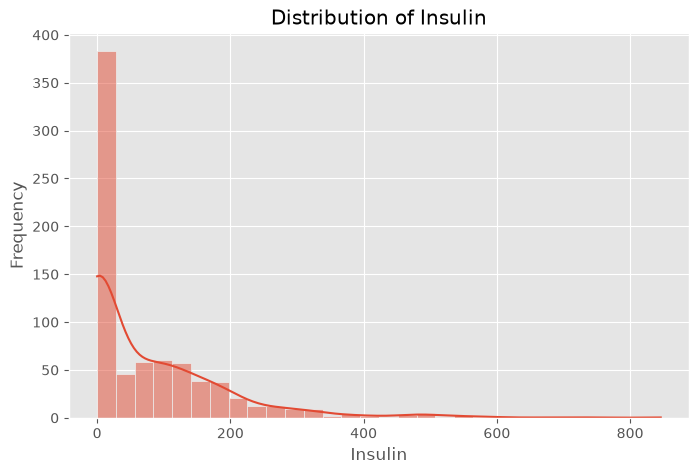

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(df['Insulin'], bins=30, kde=True)

plt.title("Distribution of Insulin")
plt.xlabel("Insulin")
plt.ylabel("Frequency")

plt.show()

### Observation

- The insulin distribution is highly right-skewed.
- Many observations have insulin values close to zero.
- Several extreme values are present, indicating possible outliers or invalid zero values.

## Summary

The univariate analysis reveals that:

- Glucose, BMI, and Age exhibit meaningful distributions with slight positive skewness.
- Insulin is highly skewed and contains many zero values, suggesting that preprocessing may be required.
- These insights help identify features that may need transformation or special handling before model training.

# 9. Outlier Detection

Outliers are observations that differ significantly from the majority of the data. Detecting outliers is important because they can influence statistical analysis and machine learning model performance. In this section, box plots are used to identify potential outliers in key numerical features.

## 9.1 Glucose

The box plot below is used to identify outliers in glucose levels.

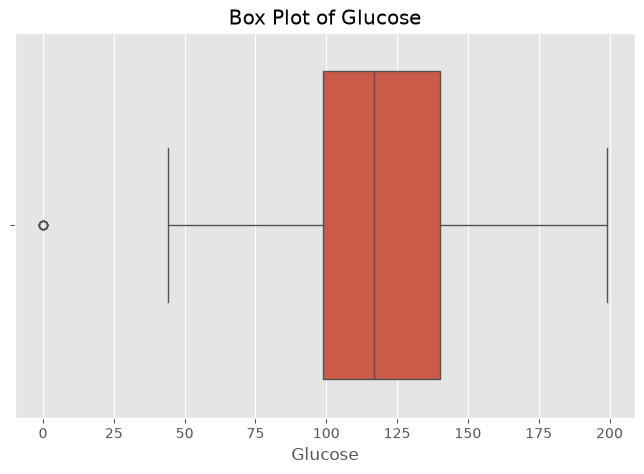

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['Glucose'])

plt.title("Box Plot of Glucose")

plt.show()

### Observation

- Most glucose values are concentrated within the interquartile range (IQR).
- A few high glucose values appear as outliers.
- These observations may represent patients with unusually high glucose levels.

## 9.2 BMI

The following box plot helps identify unusual BMI values.

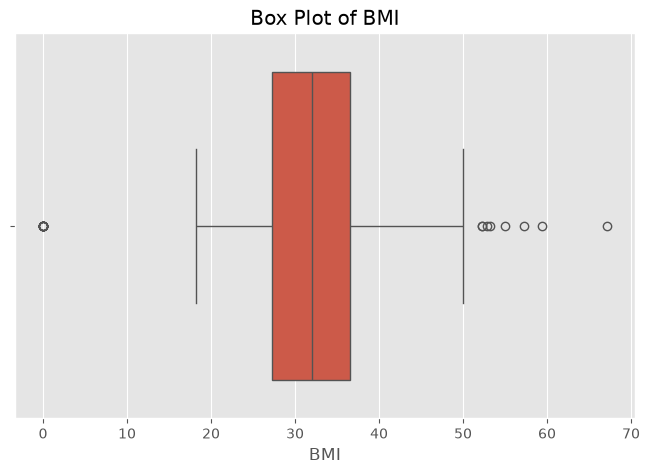

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['BMI'])

plt.title("Box Plot of BMI")

plt.show()

### Observation

- BMI contains several high-value outliers.
- These observations may represent individuals with unusually high body mass index.

## 9.3 Age

The box plot below illustrates the spread of patient ages and highlights potential outliers.

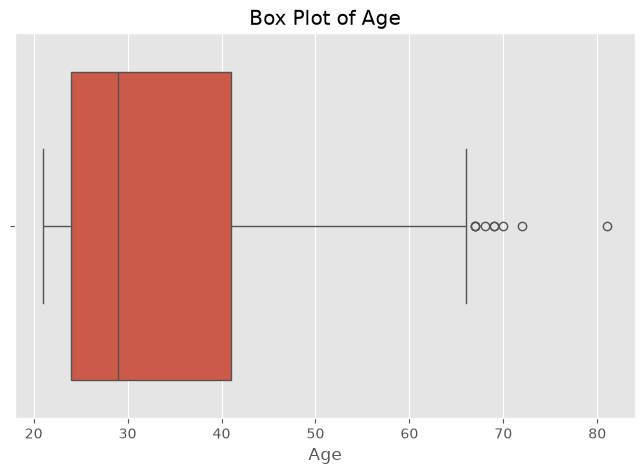

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['Age'])

plt.title("Box Plot of Age")

plt.show()

### Observation

- Most patients belong to younger age groups.
- A small number of older patients appear as outliers.

## 9.4 Insulin

This box plot highlights the distribution of insulin levels and any extreme observations.

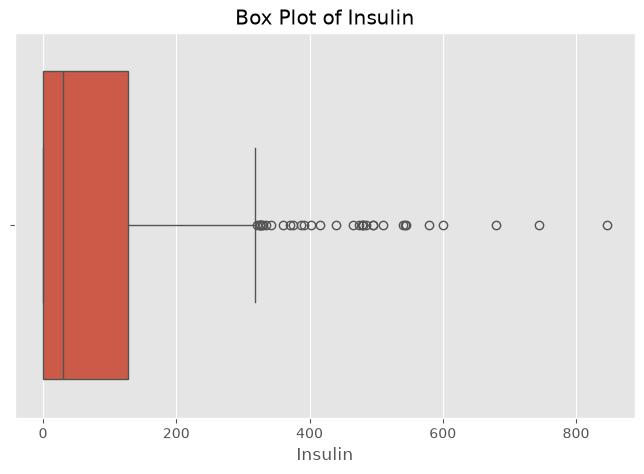

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['Insulin'])

plt.title("Box Plot of Insulin")

plt.show()

### Observation

- Insulin contains a large number of outliers.
- The feature is highly skewed and includes several extreme values.
- Appropriate preprocessing techniques may be considered before model training.

## Summary

The outlier analysis indicates that Glucose, BMI, Age, and Insulin contain extreme values. These outliers may influence model performance and should be carefully considered during the preprocessing stage. However, since these values may represent genuine medical cases, they should not be removed without proper justification.

# 10. Conclusions

The exploratory data analysis provided valuable insights into the Diabetes dataset.

### Key Findings

- The dataset contains no missing (NaN) values.
- Several medical features contain invalid zero values that require preprocessing.
- The target variable is moderately imbalanced, with more non-diabetic than diabetic patients.
- Glucose has the strongest positive correlation with diabetes, followed by BMI, Age, and Pregnancies.
- Insulin is highly skewed and contains many extreme values.
- Outlier analysis identified several unusual observations that should be handled carefully during preprocessing.

### Conclusion

Overall, the dataset is suitable for machine learning after appropriate preprocessing. The insights obtained from this exploratory data analysis will guide feature engineering, data cleaning, and model development in the next phase of the project.